# K-Means Algorithm

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator
from sklearn.decomposition import PCA

In [2]:
df =  pd.read_csv('../data/auto-mpg.csv')

In [3]:
non_numeric_hp = df[~df['horsepower'].str.replace('.','',1).str.isnumeric()]['horsepower'].unique()
print("Non-numeric horsepower values: ", non_numeric_hp)

Non-numeric horsepower values:  <StringArray>
['?']
Length: 1, dtype: str


In [4]:
df['horsepower'] = pd.to_numeric(df['horsepower'].replace('?', np.nan))
print(df['horsepower'].isnull().sum())

6


In [5]:
mean_hp = df['horsepower'].mean()
df['horsepower'] = df['horsepower'].fillna(mean_hp)
print(df['horsepower'].isnull().sum())

0


In [6]:
features = ['mpg', 'displacement', 'horsepower', 'weight']
X = df[features]

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
inertia = []
k_range = range(1,11)

In [9]:
for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [10]:
knee = KneeLocator(k_range, inertia, curve = 'convex', direction = 'decreasing')
optimal_k = knee.knee

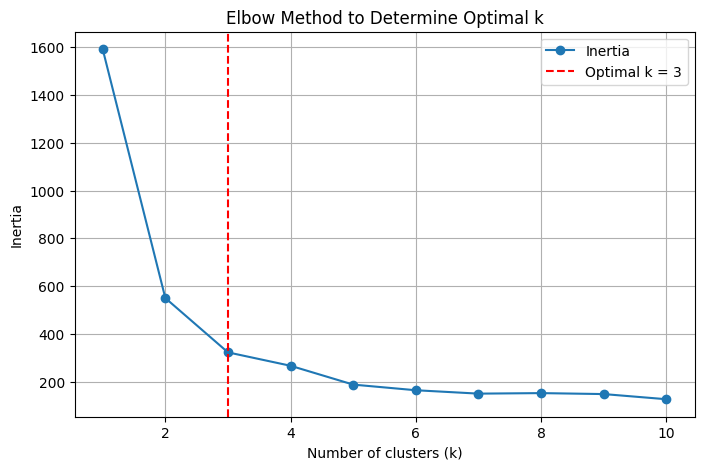

The optimal number of clusters (k) is 3


In [12]:
plt.figure(figsize = (8,5))
plt.plot(k_range, inertia, marker = 'o', label = 'Inertia')
plt.axvline(x = optimal_k, color = 'r', linestyle = '--', label = f'Optimal k = {optimal_k}')
plt.title('Elbow Method to Determine Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.legend()
plt.grid(True)
plt.show()
print(f'The optimal number of clusters (k) is {optimal_k}')

# Otra cosa

In [13]:
features = ['mpg', 'displacement', 'horsepower', 'weight']
X = df[features]

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
k = 3
kmeans = KMeans(n_clusters = k, random_state = 42)
clusters = kmeans.fit_predict(X_scaled)

In [16]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

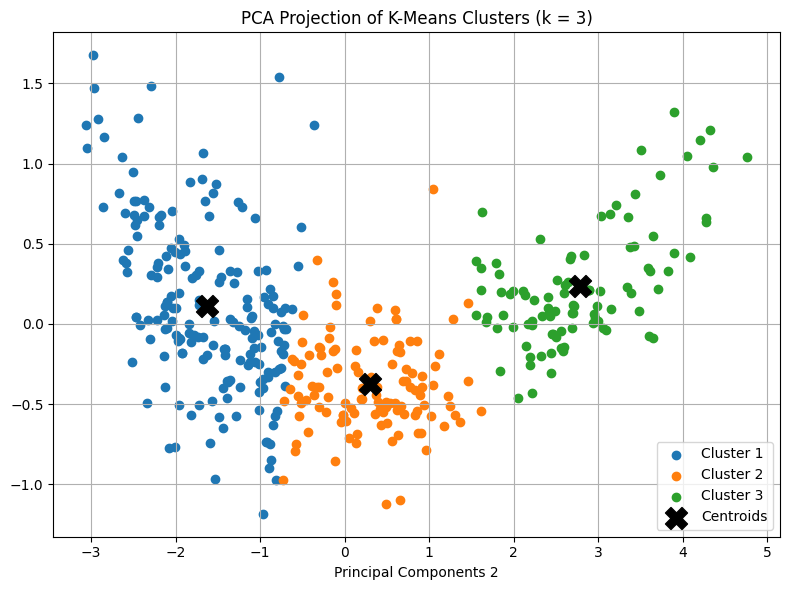

In [17]:
plt.figure(figsize = (8, 6))
for cluster_id in range(k):
    plt.scatter(
        X_pca[clusters == cluster_id, 0],
        X_pca[clusters == cluster_id, 1], 
        label = f'Cluster {cluster_id+1}'
    )

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    s = 250, c='Black', marker = 'X', label = 'Centroids'
)

plt.title('PCA Projection of K-Means Clusters (k = 3)')
plt.xlabel('Principal Components 1')
plt.xlabel('Principal Components 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

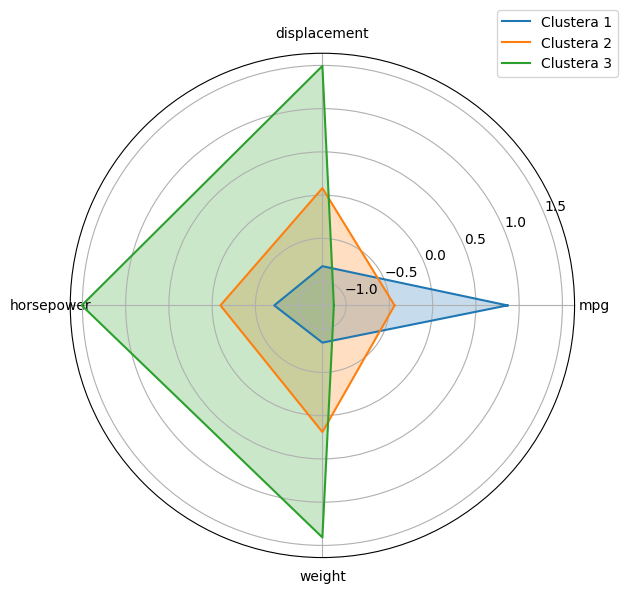

In [18]:
df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_centers_scaled = kmeans.cluster_centers_

labels = features
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint = False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize =(8, 6), subplot_kw = dict(polar = True))

for i in range(3):
    values = cluster_centers_scaled[i].tolist()
    values += values[:1]
    ax.plot(angles, values, label = f'Clustera {i+1}')
    ax.fill(angles, values, alpha = 0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.legend(loc = 'upper right', bbox_to_anchor = (1.1, 1.1))
plt.tight_layout()
plt.show()